In [12]:
width = 80

print("Министерство науки и высшего образования Российской Федерации".center(width))
print("ФГБОУ ВО Ульяновский государственный технический университет".center(width))
print("Кафедра «Вычислительная техника»".center(width))

print("\n\n")

print("Лабораторная работа №4".center(width))
print("«Основы нейронных сетей»".center(width))

print("\n")

print("Выполнил студент группы ИВТИИбд-31".rjust(width))
print("Бугров Д.А.".rjust(width))

print("\n")
print("Ульяновск, 2024".center(width))


         Министерство науки и высшего образования Российской Федерации          
          ФГБОУ ВО Ульяновский государственный технический университет          
                        Кафедра «Вычислительная техника»                        



                             Лабораторная работа №4                             
                            «Основы нейронных сетей»                            


                                              Выполнил студент группы ИВТИИбд-31
                                                                     Бугров Д.А.


                                Ульяновск, 2024                                 



Общее задание
Перед выполнением лабораторной работы необходимо загрузить набор данных в соответствии с вариантом на диск

1.Написать программу, которая разделяет исходную выборку на обучающую и тестовую (training set, validation set, test set), если такое разделение не предусмотрено предложенным набором данных.

2. Произвести масштабирование признаков (scaling).

3. С использованием библиотеки scikit-learn обучить 2 модели нейронной сети (Perceptron и MLPClassifier) по обучающей выборке. Перед обучением необходимо осуществить масштабирование признаков.

4. Проверить точность модели по тестовой выборке

5. Провести эксперименты и определить наилучшие параметры коэффициента обучения, параметра регуляризации, функции оптимизации. Данные экспериментов необходимо представить в отчете (графики, ход проведения эксперимента, выводы).

Изучим наш dataframe "data_banknote_authentication":
 Согласно описанию, набор данных представляет из себя список характеристик изображений, полученных с подлинных и поддельных банкнот после применения инструмента вейвлет-преобразования. Смысл заключается в том, что в реальности для проверки купюры используются специальные сканеры или спектрометры (в нашем случае данные получены с помощью промышленной камеры). Если обработать изображение банкноты математическими методами - можно уловить мелкие отличия, которые не видны визуально, например зернистость бумаги или качество печати.

Вейвлет-преобразование позволяет разложить сигнал (или изображение в нашем случае) на волны разной частоты и масштаба. Так мы можем увидеть, где в изображении находятся высокие и низкие частоты. Низкие частоты в свою очередь показывают грубую структуру - общий фон, большие элементы(линии, водяные знаки). А высокие частоты показывают мелкие детали - шум, зернистость, дефекты печати, фактуру бумаги.
После вейвлет-преобразования с помощью статистических методов получают следующие показатели:

1. Varience (дисперсия) - разброс яркости (поддельная купюра часто печается другими чернилами, другой контрастности)
2. Skewness (ассиметрия) - наклон распределения яркости. (у поддельных банкнот тон распределения может быть смещён, т.е быть темнее или светлее в среднем)
3. Curtosis (эксцесс) - острота распределения. (у настоящей купюры детали печати чёткие, у подделки более "плоские")
4. Entropy (энтропия) - степень случайности. (у подделки может быть больше "шума", неровностей или наоборот - слишком однородная структура)

Таким образом, набор данных содержит 5 признаков:
Varience, Skewness, Curtosis, Entropy, Class
, где Class - тип банкоты (0 - настоящая, 1 - поддельная)

Применим метод read_csv() для чтения .txt файла. Для этого укажем параметр header = None, и зададим имя столбцов в массиве names:

Зададим параметр statify метода train_test_split() как stratify = y - это позволяет делить данные так, чтобы соотношение классов сохранялось одинаковым во всех частях (выборка стратифицированная).

Также зададим параметр normalize=True метода value_counts в строках 18-20 для выражения значений в долях (распределение классов).

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("data_banknote_authentication.txt", header = None, names = ['variance', 'skewness', 'curtosis', 'entropy', 'class'])

X = df.drop('class', axis=1)
y = df['class']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val)

# размеры выборок
print("Train size:", X_train.shape, y_train.shape)
print("Validation size:", X_val.shape, y_val.shape)
print("Test size:", X_test.shape, y_test.shape)

# распределение классов
print("Train balance:\n", y_train.value_counts(normalize=True))
print("Val balance:\n", y_val.value_counts(normalize=True))
print("Test balance:\n", y_test.value_counts(normalize=True))

Train size: (960, 4) (960,)
Validation size: (206, 4) (206,)
Test size: (206, 4) (206,)
Train balance:
 class
0    0.55625
1    0.44375
Name: proportion, dtype: float64
Val balance:
 class
0    0.553398
1    0.446602
Name: proportion, dtype: float64
Test balance:
 class
0    0.553398
1    0.446602
Name: proportion, dtype: float64


2. Произвести масштабирование признаков (scaling).

In [13]:
from sklearn.preprocessing import StandardScaler

# Проверяем, как выглядят масштабированные данные
print("X_train до масштабирования")
print(X_train.head(5))
print("\n")

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Проверяем, как выглядят масштабированные данные
print("X_train после масштабирования")
print(X_train_scaled[:5])

X_train до масштабирования
      variance  skewness  curtosis  entropy
737    4.15420   7.27560  -2.47660  -1.2099
1331   0.22432  -0.52147  -0.40386   1.2017
1128  -2.18020   3.37910  -1.22560  -2.6621
398    4.39370   0.35798   2.04160   1.2004
634    6.82480   5.21870  -2.54250   0.5461


X_train после масштабирования
[[ 1.29259734  0.92578779 -0.89765492 -0.01760146]
 [-0.08446575 -0.39775334 -0.42347976  1.12723097]
 [-0.92702984  0.26436266 -0.61146701 -0.70698845]
 [ 1.37652016 -0.248468    0.13596156  1.12661384]
 [ 2.2283981   0.57663205 -0.91273068  0.81600517]]


3. С использованием библиотеки scikit-learn обучить 2 модели нейронной сети (Perceptron и MLPClassifier) по обучающей выборке.
    персептрон вычисляет взвешенную сумму $ z = \langle w, X \rangle + b $

Подробнее разберём алгоритм обучения персептрона.

1. Инициализация:
    веса w и свободный член b инициализируются случайно (или нулями). в нашем случае это контролируется параметром random_state = 42.
    задаётся скорость обучения (learning rate), которая определяет, насколько сильно изменяются веса на каждой итерации.
2. Обучение:
    персептрон проходит по каждому примеру из обучающей выборки. для каждого примера вычисляется взвешенная сумма и применяется пороговая функция активации:
        $\hat{y}_i = \begin{cases}
1, & \text{если } z \geq 0, \\
0, & \text{если } z < 0.
\end{cases}$

    если предсказание верное, то веса не изменяются. иначе веса и свободный член обновляются, чтобы исправить ошибку: $$w \gets w + \eta (y_i - \hat{y}_i) X_i$$
$$b \gets b + \eta (y_i - \hat{y}_i)$$

Обучим персептрон на наших данных и вычислим точность предсказания на обучающей выборке, значения весов и свободного члена персептрона.

Все веса признаков имеют отрицательное значение. Что это значит? Отрицательное значение веса говорит о том, что признак имеет обратное влияние (при увеличении признака z уменьшается) на принадлежность к классу 1. Положительное же значение, наоборот, означает, что увеличение признака увеличивает z, сдвигая точку к классу 1.

In [27]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier

perceptron = Perceptron(random_state=42, max_iter=1000, tol=1e-3)
perceptron.fit(X_train_scaled, y_train)

# Предсказание на train для проверки
y_train_pred_perceptron = perceptron.predict(X_train_scaled)
train_accuracy_perceptron = accuracy_score(y_train, y_train_pred_perceptron)
print("Perceptron: Точность на обучающей выборке:", train_accuracy_perceptron)

#Обучение MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Предсказание на train для проверки
y_train_pred_mlp = mlp.predict(X_train_scaled)
train_accuracy_mlp = accuracy_score(y_train, y_train_pred_mlp)
print("MLPClassifier: Точность на обучающей выборке:", train_accuracy_mlp)

# Вывод весов Perceptron (для понимания)
print("\nВеса Perceptron (w):", perceptron.coef_)
print("Свободный член Perceptron (b):", perceptron.intercept_)



Perceptron: Точность на обучающей выборке: 0.990625
MLPClassifier: Точность на обучающей выборке: 1.0

Веса Perceptron (w): [[-13.86791048 -14.81665963 -12.8733701   -0.84085825]]
Свободный член Perceptron (b): [-6.]


4. Проверить точность модели по тестовой выборке.

Perceptron:
Точность на обучающей выборке: 0.9906
Точность на валидационной выборке: 0.9757
Точность на тестовой выборке: 0.9903

MLPClassifier:
Точность на обучающей выборке: 1.0000
Точность на валидационной выборке: 1.0000
Точность на тестовой выборке: 1.0000


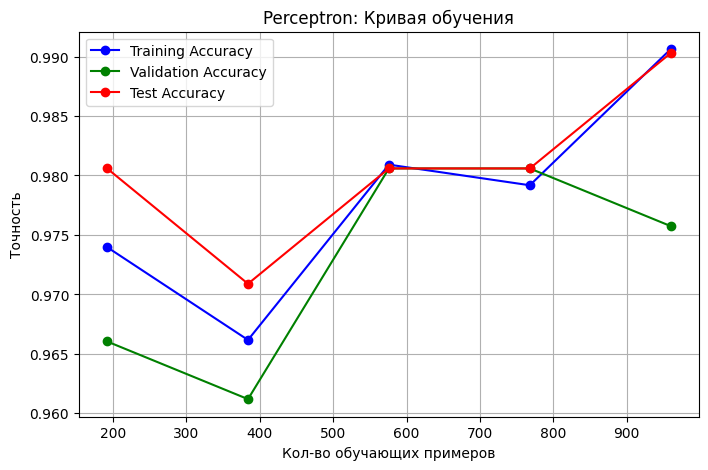

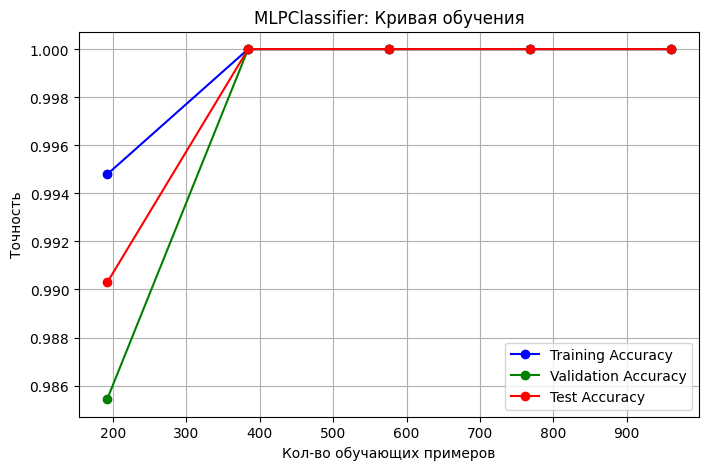

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Загрузка данных
df = pd.read_csv("data_banknote_authentication.txt", header=None, names=['variance', 'skewness', 'curtosis', 'entropy', 'class'])
X = df.drop('class', axis=1)
y = df['class']

# Разделение данных
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val)

# Масштабирование данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Инициализация моделей
perceptron = Perceptron(random_state=42, max_iter=1000, tol=1e-3)
mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=1000, random_state=42)

# Обучение моделей
perceptron.fit(X_train_scaled, y_train)
mlp.fit(X_train_scaled, y_train)

# Предсказания и точность
y_train_pred_perceptron = perceptron.predict(X_train_scaled)
y_val_pred_perceptron = perceptron.predict(X_val_scaled)
y_test_pred_perceptron = perceptron.predict(X_test_scaled)
train_accuracy_perceptron = accuracy_score(y_train, y_train_pred_perceptron)
val_accuracy_perceptron = accuracy_score(y_val, y_val_pred_perceptron)
test_accuracy_perceptron = accuracy_score(y_test, y_test_pred_perceptron)

y_train_pred_mlp = mlp.predict(X_train_scaled)
y_val_pred_mlp = mlp.predict(X_val_scaled)
y_test_pred_mlp = mlp.predict(X_test_scaled)
train_accuracy_mlp = accuracy_score(y_train, y_train_pred_mlp)
val_accuracy_mlp = accuracy_score(y_val, y_val_pred_mlp)
test_accuracy_mlp = accuracy_score(y_test, y_test_pred_mlp)

# Вывод точности
print("Perceptron:")
print(f"Точность на обучающей выборке: {train_accuracy_perceptron:.4f}")
print(f"Точность на валидационной выборке: {val_accuracy_perceptron:.4f}")
print(f"Точность на тестовой выборке: {test_accuracy_perceptron:.4f}")
print("\nMLPClassifier:")
print(f"Точность на обучающей выборке: {train_accuracy_mlp:.4f}")
print(f"Точность на валидационной выборке: {val_accuracy_mlp:.4f}")
print(f"Точность на тестовой выборке: {test_accuracy_mlp:.4f}")

# Упрощённая функция для построения кривых обучения
def plot_simple_learning_curve(estimator, title, X_train, y_train, X_val, y_val, X_test, y_test):
    # Уменьшаем число размеров обучающей выборки до 5 для простоты
    train_sizes = np.linspace(0.2, 1.0, 5)  # 20%, 40%, 60%, 80%, 100% от обучающей выборки
    train_scores = []
    val_scores = []
    test_scores = []

    # Вычисляем точность для каждого размера выборки
    for size in train_sizes:
        # Индексы для части обучающей выборки
        n_samples = int(len(X_train) * size)
        X_subset = X_train[:n_samples]
        y_subset = y_train[:n_samples]

        # Обучаем модель на подмножестве
        estimator.fit(X_subset, y_subset)

        # Точность на обучающей выборке
        train_pred = estimator.predict(X_subset)
        train_scores.append(accuracy_score(y_subset, train_pred))

        # Точность на валидационной выборке
        val_pred = estimator.predict(X_val)
        val_scores.append(accuracy_score(y_val, val_pred))

        # Точность на тестовой выборке
        test_pred = estimator.predict(X_test)
        test_scores.append(accuracy_score(y_test, test_pred))

    # Создаём график
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes * len(X_train), train_scores, 'o-', label='Training Accuracy', color='blue')
    plt.plot(train_sizes * len(X_train), val_scores, 'o-', label='Validation Accuracy', color='green')
    plt.plot(train_sizes * len(X_train), test_scores, 'o-', label='Test Accuracy', color='red')
    plt.xlabel('Кол-во обучающих примеров')
    plt.ylabel('Точность')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Построение кривых обучения
plot_simple_learning_curve(perceptron, 'Perceptron: Кривая обучения', X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test)
plot_simple_learning_curve(mlp, 'MLPClassifier: Кривая обучения', X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test)

Лучшие параметры для MLPClassifier: {'alpha': 0.0001, 'learning_rate_init': 0.0001, 'solver': 'lbfgs'}
Лучшая точность на кросс-валидации: 1.0000
Точность на тестовой выборке: 1.0000

Таблица результатов GridSearchCV (топ-5 комбинаций):
   param_learning_rate_init  param_alpha param_solver  mean_test_score
2                    0.0001       0.0001        lbfgs              1.0
5                    0.0010       0.0001        lbfgs              1.0
3                    0.0010       0.0001         adam              1.0
6                    0.0100       0.0001         adam              1.0
8                    0.0100       0.0001        lbfgs              1.0


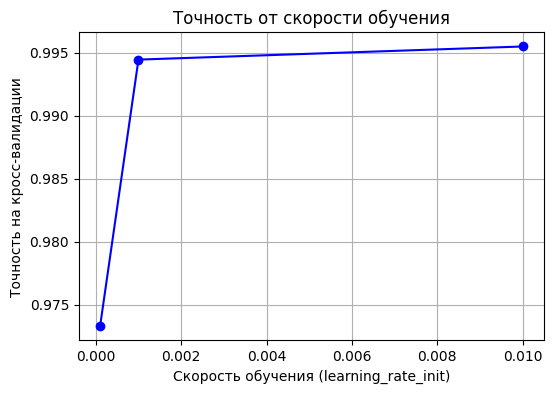

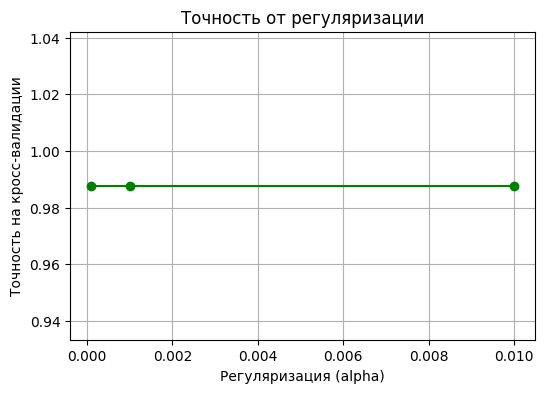

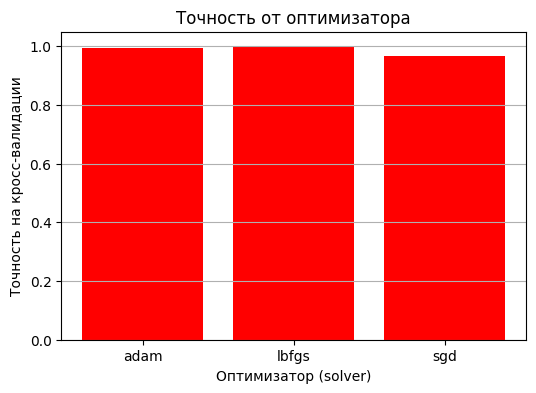

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Сетка параметров для MLPClassifier
param_grid = {
    'learning_rate_init': [0.0001, 0.001, 0.01],  # Скорость обучения
    'alpha': [0.0001, 0.001, 0.01],              # Регуляризация
    'solver': ['adam', 'sgd', 'lbfgs']           # Оптимизаторы
}

# Инициализация модели
mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', max_iter=1000, random_state=42)

# Поиск лучших параметров
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='accuracy', n_jobs=-1, return_train_score=True)
grid_search.fit(X_train_scaled, y_train)

# Вывод лучших параметров
print("Лучшие параметры для MLPClassifier:", grid_search.best_params_)
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_:.4f}")

# Проверка лучшей модели на тестовой выборке
best_mlp = grid_search.best_estimator_
y_test_pred = best_mlp.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Точность на тестовой выборке: {test_accuracy:.4f}")

# Таблица результатов GridSearchCV
results = pd.DataFrame(grid_search.cv_results_)
results_table = results[['param_learning_rate_init', 'param_alpha', 'param_solver', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False)
print("\nТаблица результатов GridSearchCV (топ-5 комбинаций):")
print(results_table.head())


# 1. Точность от learning_rate_init (усреднённая по alpha и solver)
plt.figure(figsize=(6, 4))
mean_scores_lr = results.groupby('param_learning_rate_init')['mean_test_score'].mean()
plt.plot(mean_scores_lr.index, mean_scores_lr, 'o-', color='blue')
plt.xlabel('Скорость обучения (learning_rate_init)')
plt.ylabel('Точность на кросс-валидации')
plt.title('Точность от скорости обучения')
plt.grid(True)
plt.show()

# 2. Точность от alpha (усреднённая по learning_rate_init и solver)
plt.figure(figsize=(6, 4))
mean_scores_alpha = results.groupby('param_alpha')['mean_test_score'].mean()
plt.plot(mean_scores_alpha.index, mean_scores_alpha, 'o-', color='green')
plt.xlabel('Регуляризация (alpha)')
plt.ylabel('Точность на кросс-валидации')
plt.title('Точность от регуляризации')
plt.grid(True)
plt.show()

# 3. Точность от solver (усреднённая по learning_rate_init и alpha)
plt.figure(figsize=(6, 4))
mean_scores_solver = results.groupby('param_solver')['mean_test_score'].mean()
plt.bar(mean_scores_solver.index, mean_scores_solver, color='red')
plt.xlabel('Оптимизатор (solver)')
plt.ylabel('Точность на кросс-валидации')
plt.title('Точность от оптимизатора')
plt.grid(True, axis='y')
plt.show()